In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
import numpy as np

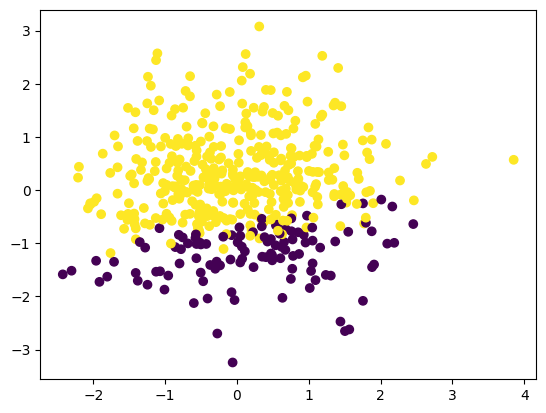

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [4]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.5104, Val loss: 0.5097
100. Training loss: 0.4756, Val loss: 0.4777
150. Training loss: 0.4466, Val loss: 0.4511
200. Training loss: 0.4224, Val loss: 0.4289
250. Training loss: 0.4021, Val loss: 0.4103
300. Training loss: 0.3848, Val loss: 0.3944
350. Training loss: 0.3700, Val loss: 0.3808
400. Training loss: 0.3572, Val loss: 0.3691
450. Training loss: 0.3461, Val loss: 0.3589
500. Training loss: 0.3363, Val loss: 0.3499
550. Training loss: 0.3277, Val loss: 0.3419
600. Training loss: 0.3200, Val loss: 0.3348
650. Training loss: 0.3131, Val loss: 0.3284
700. Training loss: 0.3068, Val loss: 0.3226
750. Training loss: 0.3012, Val loss: 0.3174
800. Training loss: 0.2960, Val loss: 0.3126
850. Training loss: 0.2912, Val loss: 0.3082
900. Training loss: 0.2869, Val loss: 0.3041
950. Training loss: 0.2828, Val loss: 0.3003
1000. Training loss: 0.2790, Val loss: 0.2968
1050. Training loss: 0.2755, Val loss: 0.2935
1100. Training loss: 0.2722, Val loss: 0.2904
1150. Tr

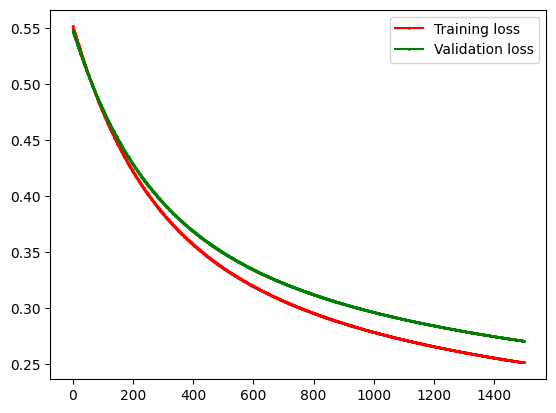

LinearModel(act_fn=<function sigmoid at 0x000002F33DD5DB20>, dim=5,
            grad_fn=<function logloss_sigmoid_grad at 0x000002F3613CD9E0>,
            loss_fn=<function logloss at 0x000002F3613CD620>)

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =1500,val_ratio=0.2)

In [6]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9231
Precision : 0.9360
Recall    : 0.9244
F1-score  : 0.9302


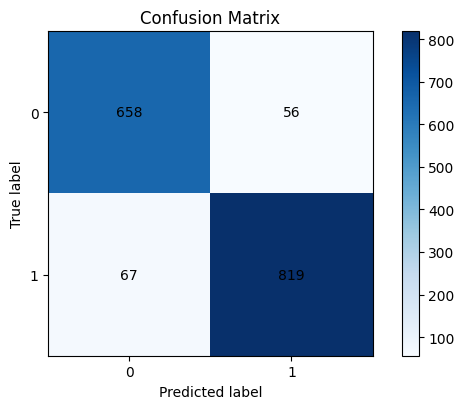

{'Accuracy': 0.923125,
 'Precision': 0.936,
 'Recall': 0.9243792325056434,
 'F1-score': 0.9301533219761499}

In [7]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

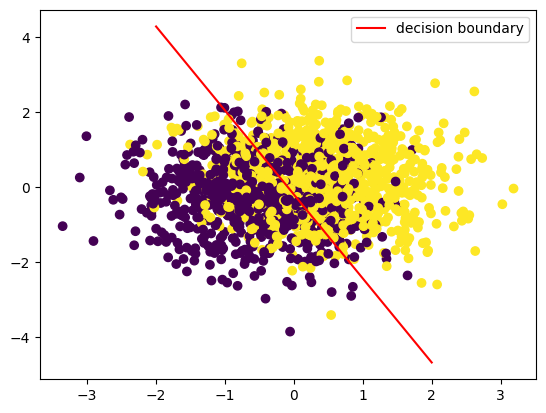

In [8]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()